# Luka's Log

In [1]:
import json
offical_run = json.load(open("LSC23.json"))
# 'id', 'name', 'description', 'started', 'ended', 'tasks', 'hasStarted', 'running', 'hasEnded'

In [2]:
descriptions = offical_run['description']
# 'id', 'name', 'description', 'taskTypes', 'taskGroups', 'tasks', 'teams', 'teamGroups', 'participantCanView'
tasks = descriptions['tasks']
# list of ['id', 'name', 'taskGroup', 'taskType', 'duration', 'mediaCollectionId', 'target', 'hints']
targets = {}
queries = {}
for i in range(len(tasks)):
    if "KIS" in tasks[i]['name']:
        targets[tasks[i]['name']] = [item['location'] for item in tasks[i]['target']['items']]
        queries[tasks[i]['name']] = [item['text'] for item in tasks[i]['hints']]
    else:
        targets[tasks[i]['name']] = []
        queries[tasks[i]['name']] = [item['text'] for item in tasks[i]['hints']]
print(len(targets), len(queries))

63 63


In [3]:
teams = offical_run['description']['teams']
# list of ['uid', 'name', 'color', 'logoId', 'users']
team_ids = {item["uid"]["string"]: item["name"] for item in teams}

In [50]:
TEAMS = list(team_ids.values())
TASKS = ["KIS", "QA", "AD"]

def task_type(name):
    if "QA" in name:
        return "QA"
    elif "KIS" in name:
        return "KIS"
    return "AD"

def make_task_dicts(data_type):
    # deep copy obj to 3 keys: AD, QA, KIS
    return {task: defaultdict(data_type) for task in TASKS}

In [5]:
tasks = offical_run['tasks']
print("Number of tasks: ", len(tasks))
# list of ['started', 'ended', 'submissions', 'description', 'filter', 'scorer', 'validator', 'duration', 'uid',
#          'taskDescriptionId', 'position', 'hasStarted', 'running', 'hasEnded', 'teamGroupAggregators']
# ['teamId', 'memberId', 'timestamp', 'item', 'uid', 'status']
submissions = {}
start_times = {}
mysceal = []
names = []
real_queries = []
real_targets = []
for i in range(len(tasks)):
    name = tasks[i]["description"]["name"]
    if name in queries:
        if name.endswith("N"): # ignore novice
            continue
        names.append(name)
        real_queries.append(queries[name])
        real_targets.append(targets[name])
        start_times[name] = tasks[i]["started"]
        if task_type(name) != "QA":
            submissions[name] = [(team_ids[item["teamId"]["string"]],
                            item["status"],
                            (item["timestamp"] - start_times[name])/1000,
                            item["item"]["name"]) for item in tasks[i]['submissions']]
        else:
            submissions[name] = [(team_ids[item["teamId"]["string"]],
                            item["status"],
                            (item["timestamp"] - start_times[name])/1000,
                            item["text"]) for item in tasks[i]['submissions']]
print(names)

Number of tasks:  30
['LSC23-KIS01', 'LSC23-AD01', 'LSC23-QA01', 'LSC23-KIS02', 'LSC23-AD02', 'LSC23-QA02', 'LSC23-KIS03', 'LSC23-AD03', 'LSC23-QA03', 'LSC23-KIS04', 'LSC23-AD04', 'LSC23-QA04', 'LSC23-KIS05', 'LSC23-AD05', 'LSC23-QA05', 'LSC23-KIS06', 'LSC23-AD06', 'LSC23-QA06']


## Correct/Incorrect

In [6]:
from collections import defaultdict
correct_counts = make_task_dicts(int)
incorrect_counts = make_task_dicts(int)
total_counts = make_task_dicts(int)
time_till_correct = defaultdict(lambda: defaultdict(lambda: None))
time_till_correct_full = defaultdict(lambda: defaultdict(lambda: 300))
top_3 = make_task_dicts(int)
limits = {"QA": 180, "KIS": 300, "AD": 180}

for team in TEAMS:
    for name in names:
        time_till_correct_full[team][name] = limits[task_type(name)]

for name in submissions:
    correct_time = 0
    task = task_type(name) 
    for team, status, time, image in submissions[name]:
        if status == "CORRECT":
            correct_counts[task][team] += 1
            time = min(time, limits[task])
            if time_till_correct[team][name]:
                time_till_correct[team][name] = min(time_till_correct[team][name], time)
            else:
                time_till_correct[team][name] = time
            
            time_till_correct_full[team][name] = min(time_till_correct_full[team][name], time)

            correct_time += 1
            if correct_time <= 3:
                top_3[task][team] += 1
        else:
            incorrect_counts[task][team] += 1

        total_counts[task][team] += 1

In [52]:

time_till_correct_full

defaultdict(<function __main__.<lambda>()>,
            {'e-LifeSeeker': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'LSC23-KIS01': 47.435,
                          'LSC23-AD01': 20.639,
                          'LSC23-QA01': 29.099,
                          'LSC23-KIS02': 26.344,
                          'LSC23-AD02': 26.636,
                          'LSC23-QA02': 180,
                          'LSC23-KIS03': 118.581,
                          'LSC23-AD03': 35.792,
                          'LSC23-QA03': 170.554,
                          'LSC23-KIS04': 70.58,
                          'LSC23-AD04': 16.259,
                          'LSC23-QA04': 64.559,
                          'LSC23-KIS05': 300,
                          'LSC23-AD05': 21.906,
                          'LSC23-QA05': 180,
                          'LSC23-KIS06': 30.386,
                          'LSC23-AD06': 17.193,
                          'LSC23-QA06': 59.532}),
 

In [53]:
# Significance test for speed
from scipy.stats import ttest_ind

for cur_task in TASKS:
    print(cur_task)
    myEachtra_scores = [time for task, time in time_till_correct_full["MyEachtra"].items() if task_type(task) == cur_task]
    print(myEachtra_scores)
    other_scores = []
    for team in TEAMS:
        if team != "MyEachtra":
            other_scores += [time for task, time in time_till_correct_full[team].items() if task_type(task) == cur_task]
    mySceal_score = [time for task, time in time_till_correct_full["2022 Baseline"].items() if task_type(task) == cur_task]

    print(ttest_ind(myEachtra_scores, other_scores))
    print(ttest_ind(myEachtra_scores, mySceal_score))
    print(ttest_ind(mySceal_score, other_scores))



KIS
[21.617, 21.468, 265.493, 13.526, 75.256, 14.927]
Ttest_indResult(statistic=-0.8060729876573616, pvalue=0.42253228970070544)
Ttest_indResult(statistic=0.6150764039500808, pvalue=0.5522430540360814)
Ttest_indResult(statistic=-1.5108752437028095, pvalue=0.13466442821953117)
QA
[25.868, 34.569, 124.15, 61.674, 180, 50.671]
Ttest_indResult(statistic=-2.086607735389062, pvalue=0.040030280552815184)
Ttest_indResult(statistic=-1.1267274218380123, pvalue=0.2861688213294393)
Ttest_indResult(statistic=-0.40292102413810915, pvalue=0.6880549071043539)
AD
[17.561, 23.681, 14.475, 15.203, 11.984, 25.854]
Ttest_indResult(statistic=-1.4078854071348605, pvalue=0.1629448634458414)
Ttest_indResult(statistic=0.5786996097785498, pvalue=0.5755932872359624)
Ttest_indResult(statistic=-1.4774616611227074, pvalue=0.14338255736055297)


### Scoring

In [7]:
import math
import numpy as np
# Scores for each queries
max_point = 100
max_point_end = 50
penalty = 10
scores = {"QA": [],
          "AD": [],
          "KIS": []}
recall_ad = defaultdict(list)
precision_ad = defaultdict(list)

for name, submission in submissions.items():
    task = task_type(name)
    if task == "AD":
        correct = defaultdict(int)
        incorrect = defaultdict(int)
        score = defaultdict(float)
        num_correct = set()
        penalty = 0.2
        
        max_time = 180
        for team, status, time, image in submission:
            if status == "WRONG":
                incorrect[team] += 1
            elif status == "CORRECT":
                correct[team] += 1
                num_correct.add(image)
                
        for team in TEAMS:
            if correct[team] == 0:
                score[team] = 0
                recall_ad[team].append(0)
                precision_ad[team].append(0)
            else:
                score[team] = correct[team] * max_point / (correct[team] + incorrect[team]/2) * correct[team] / len(num_correct)
                recall_ad[team].append(correct[team] / len(num_correct))
                precision_ad[team].append(correct[team] / (correct[team] + incorrect[team]))
    else:
        score = defaultdict(float)
        for team, status, time, image in submission:
            if status == "WRONG":
                score[team] -= penalty
            elif status == "CORRECT":
                score[team] += max_point_end + (max_point - max_point_end) * (1 - time/limits[task])
        for team in TEAMS:
            score[team] = max(0, score[team])
    scores[task].append(score)

precision_ad = {team: np.mean(precision_ad[team]) for team in TEAMS}
recall_ad = {team: np.mean(recall_ad[team]) for team in TEAMS}


In [30]:
scores["AD"]

[defaultdict(float,
             {'e-LifeSeeker': 13.489409141583053,
              'MyEachtra': 16.05351170568562,
              'MemoriEase': 22.90562036055143,
              'Vitrivr-Hybrid': 8.695652173913043,
              'LifeInsight': 45.28006267136702,
              'LifeLens': 6.521739130434782,
              'First': 5.260332796564681,
              'LifeGraph': 1.9323671497584543,
              'Memento': 39.86778540554284,
              'Memoria-MEO4J': 0.4140786749482402,
              'Memoria': 15.942028985507246,
              'lifeXplore': 14.61352657004831,
              'Voxento': 14.492753623188406,
              '2022 Baseline': 10.628019323671499}),
 defaultdict(float,
             {'e-LifeSeeker': 39.54248366013072,
              'MyEachtra': 11.764705882352942,
              'MemoriEase': 18.823529411764707,
              'Vitrivr-Hybrid': 0,
              'LifeInsight': 6.722689075630252,
              'LifeLens': 16.33986928104575,
              'First': 19.6

In [38]:
# Significance test for scores of MyEachtra and others
from scipy.stats import ttest_ind

for task in TASKS:
    print(task)
    myEachtra_score = [score["MyEachtra"] for score in scores[task]]
    other_scores = []
    for submission in scores[task]:
        other_scores.extend([score for team, score in submission.items() if team != "MyEachtra"])
    print(ttest_ind(myEachtra_score, other_scores))
    # with mysceal
    mySceal_score = [score["MySceal"] for score in scores[task]]
    print(ttest_ind(myEachtra_score, mySceal_score))

KIS
Ttest_indResult(statistic=0.9475183158766617, pvalue=0.34615873085957094)
Ttest_indResult(statistic=13.05764043849872, pvalue=1.3151205841805157e-07)
QA
Ttest_indResult(statistic=1.5635680165036652, pvalue=0.12177033474117709)
Ttest_indResult(statistic=4.80859646824652, pvalue=0.000714347519651898)
AD
Ttest_indResult(statistic=1.1757376125384962, pvalue=0.2431021115755474)
Ttest_indResult(statistic=3.1235778944741086, pvalue=0.010807960948427401)


In [8]:
from collections import defaultdict, OrderedDict
TASKS = ["KIS", "QA", "AD"]
normalize_scores = {"QA": {},
                    "AD": {},
                    "KIS": {},
                    "SUM": defaultdict(float)}
for task in TASKS:
    cum_scores = defaultdict(float)
    for score in scores[task]: # iterate over all tasks in this task_type
        for team in score:
            cum_scores[team] += score[team]
                
    max_score = max(cum_scores.values())
    for team in cum_scores:
        normalize_scores[task][team] = round(cum_scores[team]/max_score * 100)
        normalize_scores["SUM"][team] += normalize_scores[task][team]
        
# sort TEAMS by normalize_scores
TEAMS = sorted(TEAMS, key=lambda team: normalize_scores["SUM"][team], reverse=True)
for task in TASKS:
    # sort dict by TEAMS
    normalize_scores[task] = OrderedDict(sorted(normalize_scores[task].items(), key=lambda x: TEAMS.index(x[0])))
print([(team, normalize_scores["SUM"][team]) for team in TEAMS])

[('MyEachtra', 291.0), ('Memento', 263.0), ('e-LifeSeeker', 256.0), ('LifeInsight', 249.0), ('lifeXplore', 248.0), ('2022 Baseline', 246.0), ('MemoriEase', 226.0), ('First', 202.0), ('LifeGraph', 200.0), ('LifeLens', 196.0), ('Vitrivr-Hybrid', 193.0), ('Memoria', 186.0), ('Voxento', 168.0), ('Memoria-MEO4J', 162.0)]


In [9]:
normalize_scores["AD"]

OrderedDict([('MyEachtra', 96),
             ('Memento', 96),
             ('e-LifeSeeker', 92),
             ('LifeInsight', 88),
             ('lifeXplore', 100),
             ('2022 Baseline', 74),
             ('MemoriEase', 66),
             ('First', 60),
             ('LifeGraph', 58),
             ('LifeLens', 76),
             ('Vitrivr-Hybrid', 70),
             ('Memoria', 31),
             ('Voxento', 52),
             ('Memoria-MEO4J', 15)])

# GRAPHS

In [10]:
import pandas as pd
import seaborn as sns


df = None
for task in TASKS:
    data = {
        "team": TEAMS,
        "task": [f"{task}" for team in TEAMS],
        f"correct": [correct_counts[task][team] for team in TEAMS],
        f"incorrect": [incorrect_counts[task][team] for team in TEAMS],
        
        # f"cum_score_{task}": [cum_scores[task][team] for team in TEAMS],
        f"norm_score": [normalize_scores[task][team] for team in TEAMS],
    }
    if task != "AD":
        data.update({
            f"top_3": [top_3[task][team] for team in TEAMS],
            f"precision": [correct_counts[task][team]/total_counts[task][team] for team in TEAMS],
            f"recall": [correct_counts[task][team]/len(scores[task]) for team in TEAMS]})
    else:
        data["recall"] = [recall_ad[team] for team in TEAMS]
        data["precision"] = [precision_ad[team] for team in TEAMS]
    for i in time_till_correct["MyEachtra"]:
        data[f"time_correct_{i}"] = [time_till_correct[team][i] for team in TEAMS]
    for i in time_till_correct_full["MyEachtra"]:
        data[f"time_correct_full_{i}"] = [time_till_correct_full[team][i] for team in TEAMS]
    if df is None:
        df = pd.DataFrame(data=data)
    else:
        df = pd.concat([df, pd.DataFrame(data=data)], axis=0)   
        
# Change team "2022 Baseline" to "E-Myscéal"   
df["team"] = df["team"].apply(lambda x: "E-Myscéal" if x == "2022 Baseline" else x)
TEAMS = [t if t != "2022 Baseline" else "E-Myscéal" for t in TEAMS]
df

,team,task,correct,incorrect,norm_score,top_3,precision,recall,time_correct_LSC23-KIS01,time_correct_LSC23-AD01,...,time_correct_full_LSC23-QA03,time_correct_full_LSC23-KIS04,time_correct_full_LSC23-AD04,time_correct_full_LSC23-QA04,time_correct_full_LSC23-KIS05,time_correct_full_LSC23-AD05,time_correct_full_LSC23-QA05,time_correct_full_LSC23-KIS06,time_correct_full_LSC23-AD06,time_correct_full_LSC23-QA06
0,MyEachtra,KIS,6,1,95,4.0,0.857143,1.000000,21.617,17.561,...,124.150,13.526,15.203,61.674,75.256,11.984,180,14.927,25.854,50.671
1,Memento,KIS,5,7,78,0.0,0.416667,0.833333,34.502,35.379,...,69.730,109.493,23.052,76.497,164.815,25.750,180,27.315,23.464,54.868
2,e-LifeSeeker,KIS,5,6,81,0.0,0.454545,0.833333,47.435,20.639,...,170.554,70.580,16.259,64.559,300.000,21.906,180,30.386,17.193,59.532
3,LifeInsight,KIS,6,3,90,1.0,0.666667,1.000000,26.266,51.345,...,133.236,84.611,21.053,127.794,154.257,31.831,180,17.652,19.491,54.981
4,lifeXplore,KIS,6,0,96,4.0,1.000000,1.000000,60.476,26.157,...,54.210,15.406,32.673,180.000,82.628,18.604,180,15.197,38.321,180.000
5,E-Myscéal,KIS,6,2,100,3.0,0.750000,1.000000,20.219,17.210,...,173.625,14.134,20.193,62.369,17.949,14.501,180,18.477,16.717,73.132
6,MemoriEase,KIS,4,8,69,2.0,0.333333,0.666667,24.126,22.469,...,47.923,35.221,12.976,174.810,300.000,16.377,180,16.580,15.885,62.157
7,First,KIS,5,1,81,1.0,0.833333,0.833333,38.644,44.652,...,180.000,132.462,37.093,64.303,300.000,48.170,180,21.776,51.841,180.000
8,LifeGraph,KIS,5,2,80,1.0,0.714286,0.833333,55.264,39.344,...,115.543,83.535,30.259,71.768,300.000,40.740,180,34.874,23.178,180.000
9,LifeLens,KIS,5,5,74,0.0,0.500000,0.833333,31.681,18.160,...,180.000,145.228,35.397,180.000,300.000,25.514,180,25.453,29.656,180.000


In [57]:
df.to_csv('lsc.table', index=False)

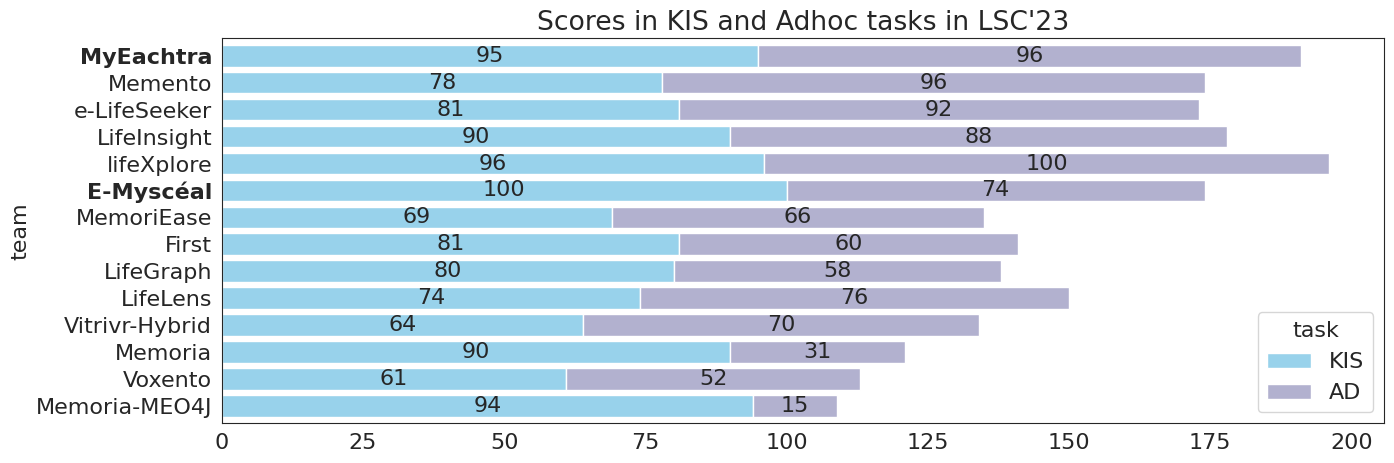

In [11]:
task_names = ["KIS", "AD"]

import matplotlib.pyplot as plt

sns.set_style("white")
plt.rcParams.update({'font.size': 16})
all_score = df.groupby(['team', 'task']).sum().reset_index().pivot(index='team', columns='task', values='norm_score')

# Sort task by ["KIS", "AD", "AD"]
all_score = all_score.reindex(columns=task_names)

# sort by the other in TEAMS
all_score = all_score.loc[TEAMS[::-1]]
fig = all_score.plot.barh(figsize=(15, 5), rot=0, stacked=True, 
                    title="Scores in KIS and Adhoc tasks in LSC'23", width=0.8,
                    color=["#98D2EB", "#B2B1CF", "#b0c5aa"], legend=True)

fig.bar_label(fig.containers[0], labels=all_score["KIS"], label_type='center')
# fig.bar_label(fig.containers[1], labels=all_score["QA"], label_type='center')
fig.bar_label(fig.containers[1], labels=all_score["AD"], label_type='center')

# Highlighting MyEachtra and E-Mysceal by fontweight
fig.axes.get_yticklabels()[-1].set_fontweight("bold")
fig.axes.get_yticklabels()[-6].set_fontweight("bold")

plt.savefig("overall_23.png", format="png", bbox_inches='tight')

In [23]:
# Significance test for scores, MyEachtra vs. the rest
from scipy.stats import ttest_ind
for task in task_names:
    # get score where team = myeachtra and task = task
    myeachtra_score = df[(df["team"] == "MyEachtra") & (df["task"] == task)]["norm_score"]
    print(task)
    print(myeachtra_score)
    for team in TEAMS:
        if team == "MyEachtra":
            continue
        team_score = df[(df["team"] == team) & (df["task"] == task)]["norm_score"]
        print(f"Significance test for {team} vs. MyEachtra in {task} task: ", ttest_ind(myeachtra_score, team_score, equal_var=False))

KIS
0    95
Name: norm_score, dtype: int64
Significance test for Memento vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for e-LifeSeeker vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for LifeInsight vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for lifeXplore vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for E-Myscéal vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for MemoriEase vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for First vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for LifeGraph vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for LifeLens vs. MyEachtra in KIS task:  Ttest_indResult(statistic=nan, pvalue=nan)
Significance test for Vitrivr-

/tmp/ipykernel_159789/1513283648.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  print(f"Significance test for {team} vs. MyEachtra in {task} task: ", ttest_ind(myeachtra_score, team_score, equal_var=False))
/home/tlduyen/.conda/envs/duyen/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/tlduyen/.conda/envs/duyen/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


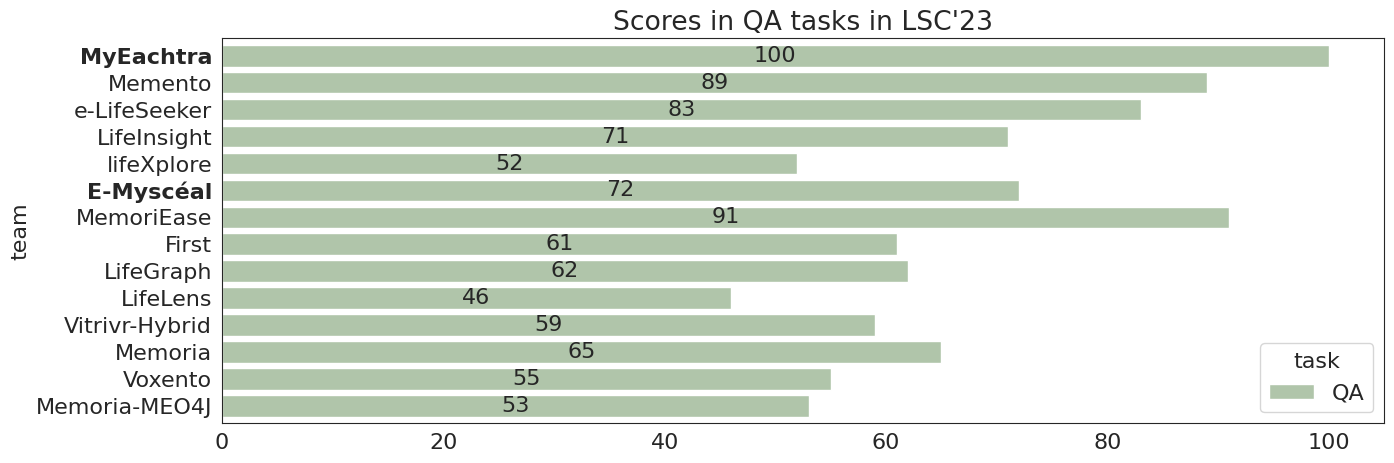

In [59]:
task_names = ["QA"]

import matplotlib.pyplot as plt

sns.set_style("white")
plt.rcParams.update({'font.size': 16})
all_score = df.groupby(['team', 'task']).sum().reset_index().pivot(index='team', columns='task', values='norm_score')

# Sort task by ["KIS", "AD", "AD"]
all_score = all_score.reindex(columns=task_names)

# sort by the other in TEAMS
all_score = all_score.loc[TEAMS[::-1]]
fig = all_score.plot.barh(figsize=(15, 5), rot=0, stacked=True, 
                    title="Scores in QA tasks in LSC'23", width=0.8,
                    color=["#b0c5aa"], legend=True)

fig.bar_label(fig.containers[0], labels=all_score["QA"], label_type='center')

# Highlighting MyEachtra and E-Mysceal by fontweight
fig.axes.get_yticklabels()[-1].set_fontweight("bold")
fig.axes.get_yticklabels()[-6].set_fontweight("bold")

plt.savefig("overall_qa_23.png", format="png", bbox_inches='tight')

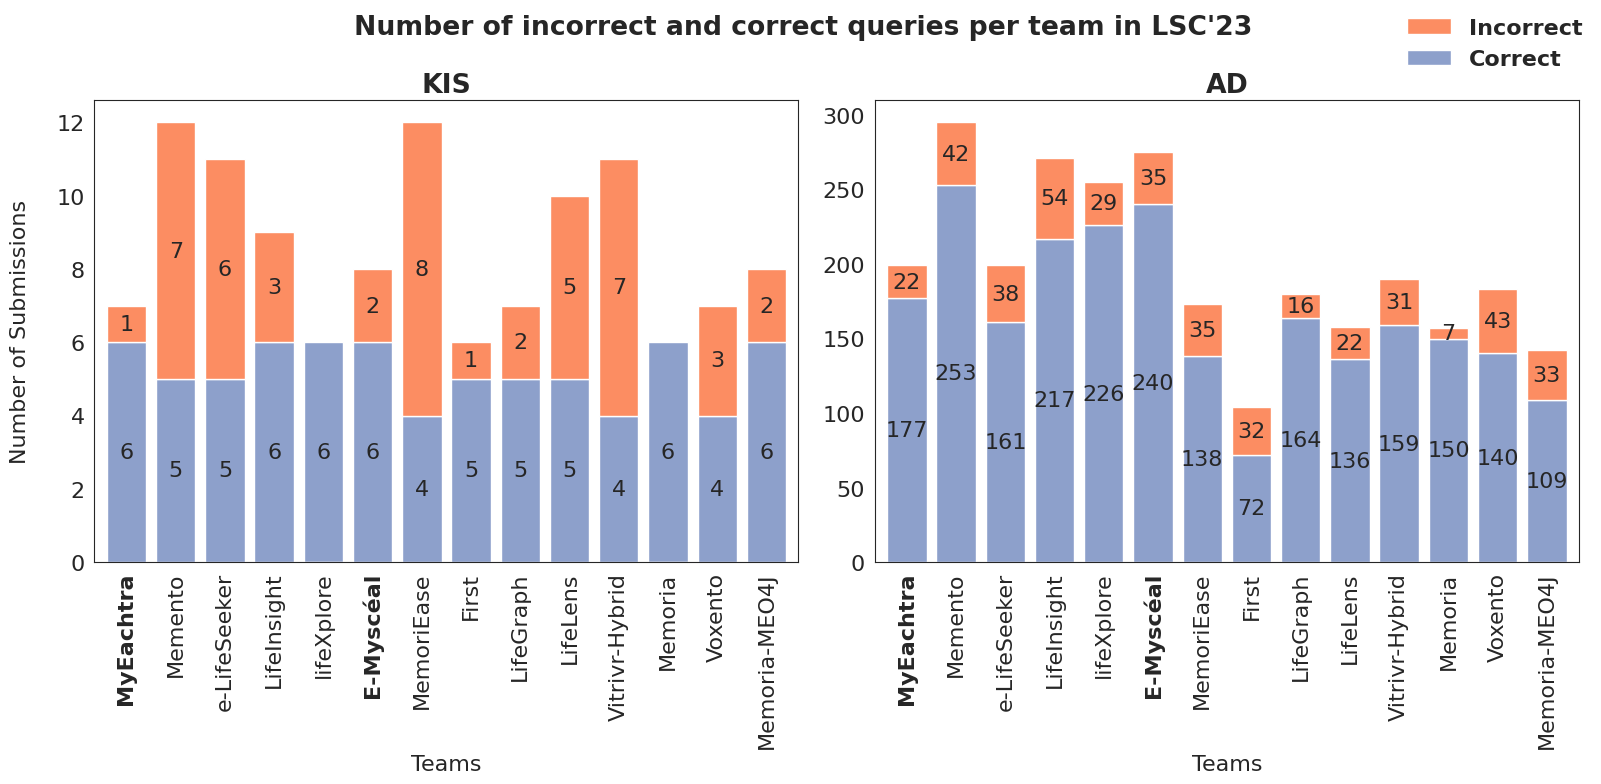

In [60]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16, 'figure.figsize': (20, 8)})
task_names = ["KIS", "AD"]
# Create subplots
fig, axes = plt.subplots(1, len(task_names), figsize=(16, 8))
# Plot data for each TASK
for i, TASK in enumerate(task_names):
    filtered = df[df["task"] == TASK]
    ax = filtered[["team", "correct", "incorrect"]].plot(x='team', kind='bar', stacked=True, width=0.8, color=["#8da0cb", "#fc8d62"], ax=axes[i])
    ax.bar_label(ax.containers[0], labels=filtered["correct"], label_type='center')
    ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["incorrect"]], label_type='center')
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Number of Submissions", va='center', rotation='vertical', transform=ax.transAxes)

    ax.get_xticklabels()[0].set_fontweight("bold")
    ax.get_xticklabels()[5].set_fontweight("bold")
    # make y-axis ends at 12
    # ax.set_ylim(0, 12)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[::-1], ["Incorrect", "Correct"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Number of incorrect and correct queries per team in LSC'23", fontweight='bold')
plt.tight_layout()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("incorrect_correct_23.png", format="pdf", bbox_inches='tight')

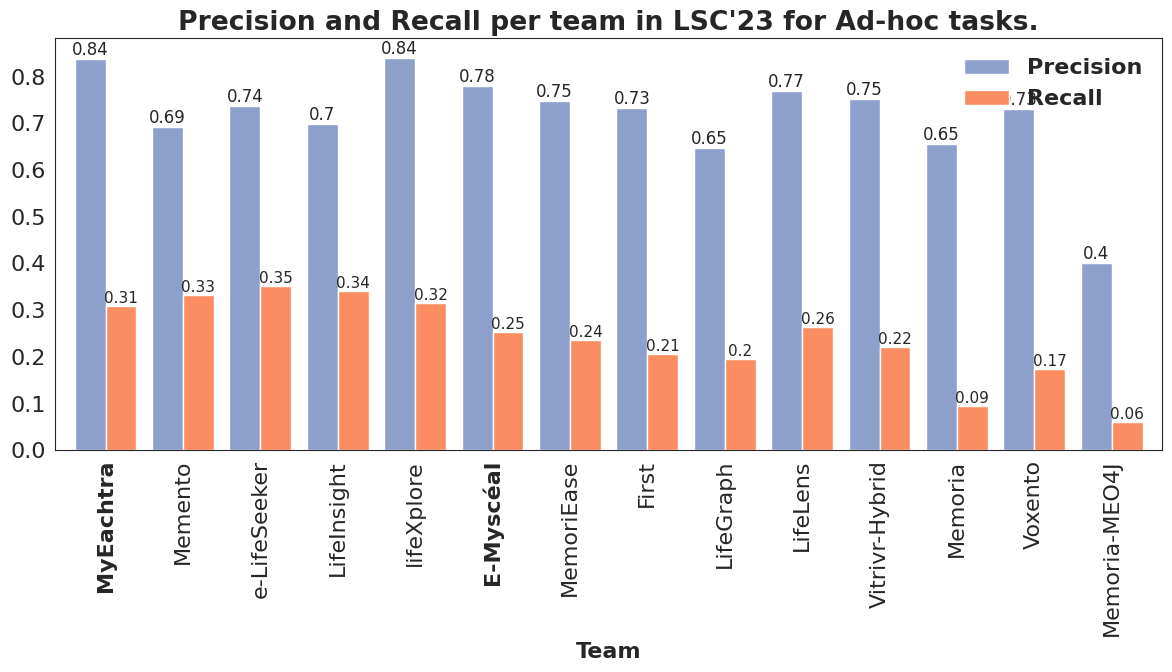

In [61]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (12, 7)

# Plot data for each TASK
filtered = df[df["task"] == "AD"]
fig = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=["#8da0cb", "#fc8d62"])
fig.bar_label(fig.containers[0], labels=filtered["precision"].round(2), label_type='edge', fontsize=12)
fig.bar_label(fig.containers[1], labels=["" if x == 0 else x for x in filtered["recall"].round(2)], label_type='edge',fontsize=11)

plt.xlabel("Team", fontweight='bold')
fig.axes.get_xticklabels()[0].set_fontweight("bold")
fig.axes.get_xticklabels()[5].set_fontweight("bold")
# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)

# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Precision and Recall per team in LSC'23 for Ad-hoc tasks.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("precision-recall_23.png", format="png", bbox_inches='tight')

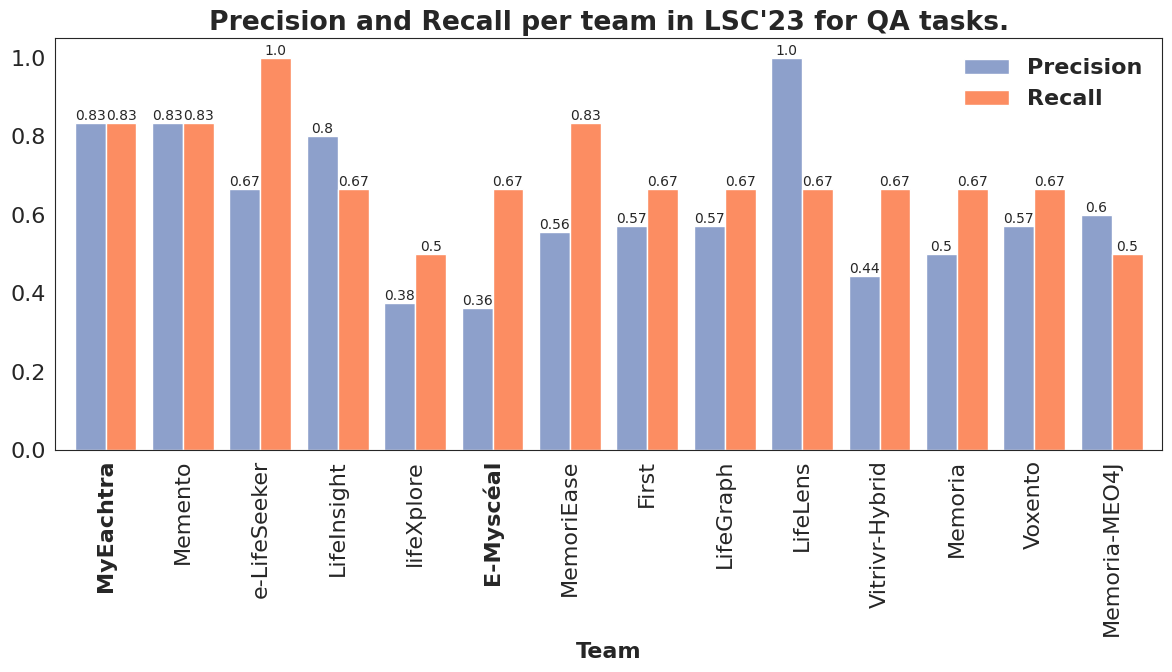

In [62]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (12, 7)

# Plot data for each TASK
filtered = df[df["task"] == "QA"]
fig = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=["#8da0cb", "#fc8d62"])
fig.bar_label(fig.containers[0], labels=filtered["precision"].round(2), label_type='edge', fontsize=10)
fig.bar_label(fig.containers[1], labels=["" if x == 0 else x for x in filtered["recall"].round(2)], label_type='edge',fontsize=10)

plt.xlabel("Team", fontweight='bold')
fig.axes.get_xticklabels()[0].set_fontweight("bold")
fig.axes.get_xticklabels()[5].set_fontweight("bold")
# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)

# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Precision and Recall per team in LSC'23 for QA tasks.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("precision-recall_23.png", format="png", bbox_inches='tight')

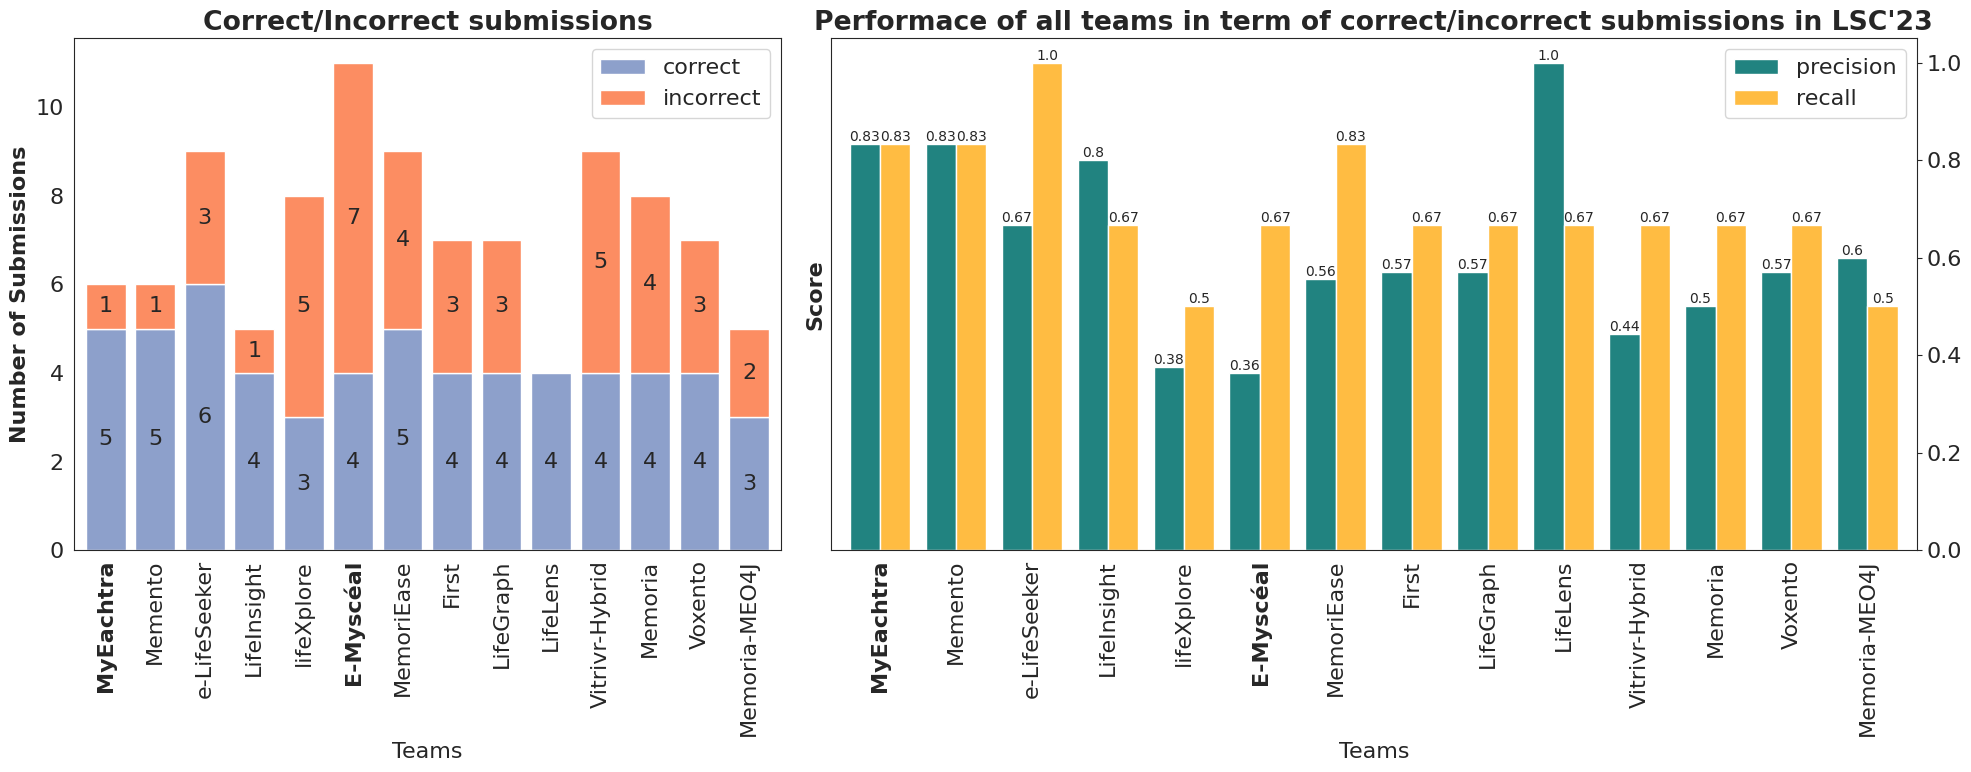

In [63]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16, 'figure.figsize': (20, 8)})
filtered = df[df["task"] == "QA"]
# Create subplots
# fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ================== Subplot 1 ================== #
i = 0 # Subplot 1, incorrect correct
plot1 = plt.subplot2grid((1, 5), (0, 0), colspan=2)

ax = filtered[["team", "correct", "incorrect"]].plot(x='team', kind='bar', stacked=True, width=0.8, color=["#8da0cb", "#fc8d62"], ax=plot1)
ax.bar_label(ax.containers[0], labels=filtered["correct"], label_type='center')
ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["incorrect"]], label_type='center')

ax.set_xlabel("Teams")
# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
ax.set_xticklabels(filtered["team"])
ax.set_ylabel("Number of Submissions", fontweight='bold')

ax.get_xticklabels()[0].set_fontweight("bold")
ax.get_xticklabels()[5].set_fontweight("bold")

# Title of the subplot
ax.set_title("Correct/Incorrect submissions", fontweight='bold')
# ================== Subplot 2 ================== #
i = 1
plot2 = plt.subplot2grid((1, 5), (0, 2), colspan=3)

ax = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=["#218380", "#FFBC42"], ax=plot2)

ax.bar_label(ax.containers[0], labels=filtered["precision"].round(2), label_type='edge', fontsize=10)
ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"].round(2)], label_type='edge',fontsize=10)

ax.set_xlabel("Teams")
ax.set_xticklabels(filtered["team"])
ax.yaxis.tick_right()
ax.set_ylabel("Score", fontweight='bold')

ax.get_xticklabels()[0].set_fontweight("bold")
ax.get_xticklabels()[5].set_fontweight("bold")
ax.set_title("Precision/Recall", fontweight='bold')

# Create a single legend for all subplots
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles[::-1], ["Incorrect", "Correct"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.title("Performace of all teams in term of correct/incorrect submissions in LSC'23", fontweight='bold')
plt.tight_layout()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("qa_23.png", format="png", bbox_inches='tight')

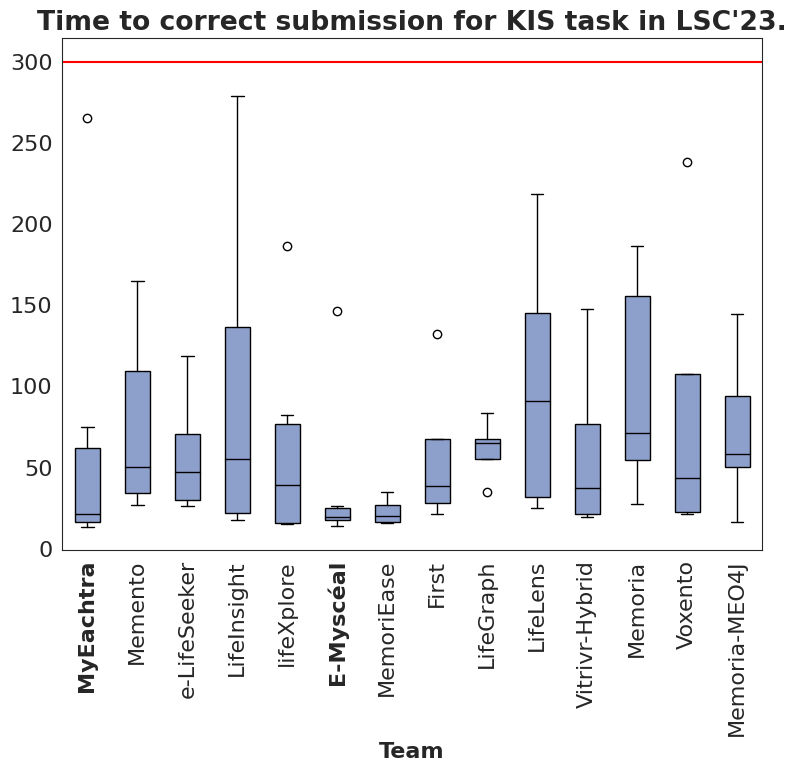

In [64]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (8, 8)

# Plot data for each TASK
filtered = df[df["task"] == "KIS"]
filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == "KIS"]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True)

plt.xlabel("Team", fontweight='bold')
plt.xticks(ticks=range(1, 15), labels=filtered["team"], rotation=90)
# set xtick label 0 and 6 in bold
plt.gca().get_xticklabels()[0].set_fontweight("bold")
plt.gca().get_xticklabels()[5].set_fontweight("bold")

# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)
plt.axhline(y=limits['KIS'], color='r', linestyle='-', label=f"Time limit: {limits['KIS']}s")
# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Time to correct submission for KIS task in LSC'23.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_23.png", format="png", bbox_inches='tight')

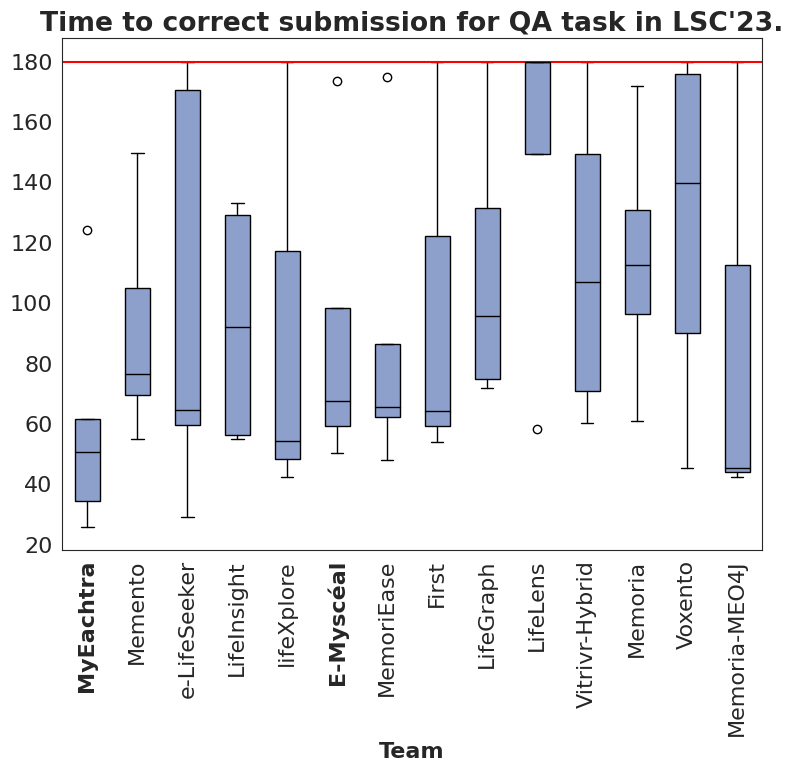

In [65]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# set figure size
plt.rcParams["figure.figsize"] = (8, 8)

# Plot data for each TASK
filtered = df[df["task"] == "QA"]
filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == "QA"]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True)

plt.xlabel("Team", fontweight='bold')
plt.xticks(ticks=range(1, 15), labels=filtered["team"], rotation=90)
# set xtick label 0 and 6 in bold
plt.gca().get_xticklabels()[0].set_fontweight("bold")
plt.gca().get_xticklabels()[5].set_fontweight("bold")

# ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')f
# make y-axis ends at 12
# ax.set_ylim(0, 12)
plt.axhline(y=limits['QA'], color='r', linestyle='-', label=f"Time limit: {limits['QA']}s")
# Turn off legend
fig.legend().set_visible(False)

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Time to correct submission for QA task in LSC'23.", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()

print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_qa_23.png", format="png", bbox_inches='tight')

In [66]:
filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == "QA"]].T.describe()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,5.000000,5.000000,5.000000,4.000000,3.000000,4.000000,5.000000,3.000000,4.000000,4.00000,4.00000,4.000000,4.000000,3.000000
mean,59.386400,91.135200,100.748800,93.170250,92.191000,89.851000,87.380400,99.466000,110.839250,149.53875,113.56075,114.628750,126.265750,89.325333
std,38.777899,37.419026,69.454551,43.184702,76.275181,56.624172,50.776753,69.930999,50.141358,60.92250,56.08217,45.516407,63.781483,78.540267
min,25.868000,54.868000,29.099000,54.981000,42.363000,50.278000,47.923000,54.095000,71.768000,58.15500,60.23200,60.966000,45.373000,42.521000
25%,34.569000,69.730000,59.532000,56.247750,48.286500,59.346250,62.157000,59.199000,74.976500,149.53875,71.05825,96.480000,90.222250,43.988000
50%,50.671000,76.497000,64.559000,92.232000,54.210000,67.750500,65.582000,64.303000,95.794500,180.00000,107.00550,112.786000,139.845000,45.455000
75%,61.674000,104.946000,170.554000,129.154500,117.105000,98.255250,86.430000,122.151500,131.657250,180.00000,149.50800,130.934750,175.888500,112.727500
max,124.150000,149.635000,180.000000,133.236000,180.000000,173.625000,174.810000,180.000000,180.000000,180.00000,180.00000,171.977000,180.000000,180.000000


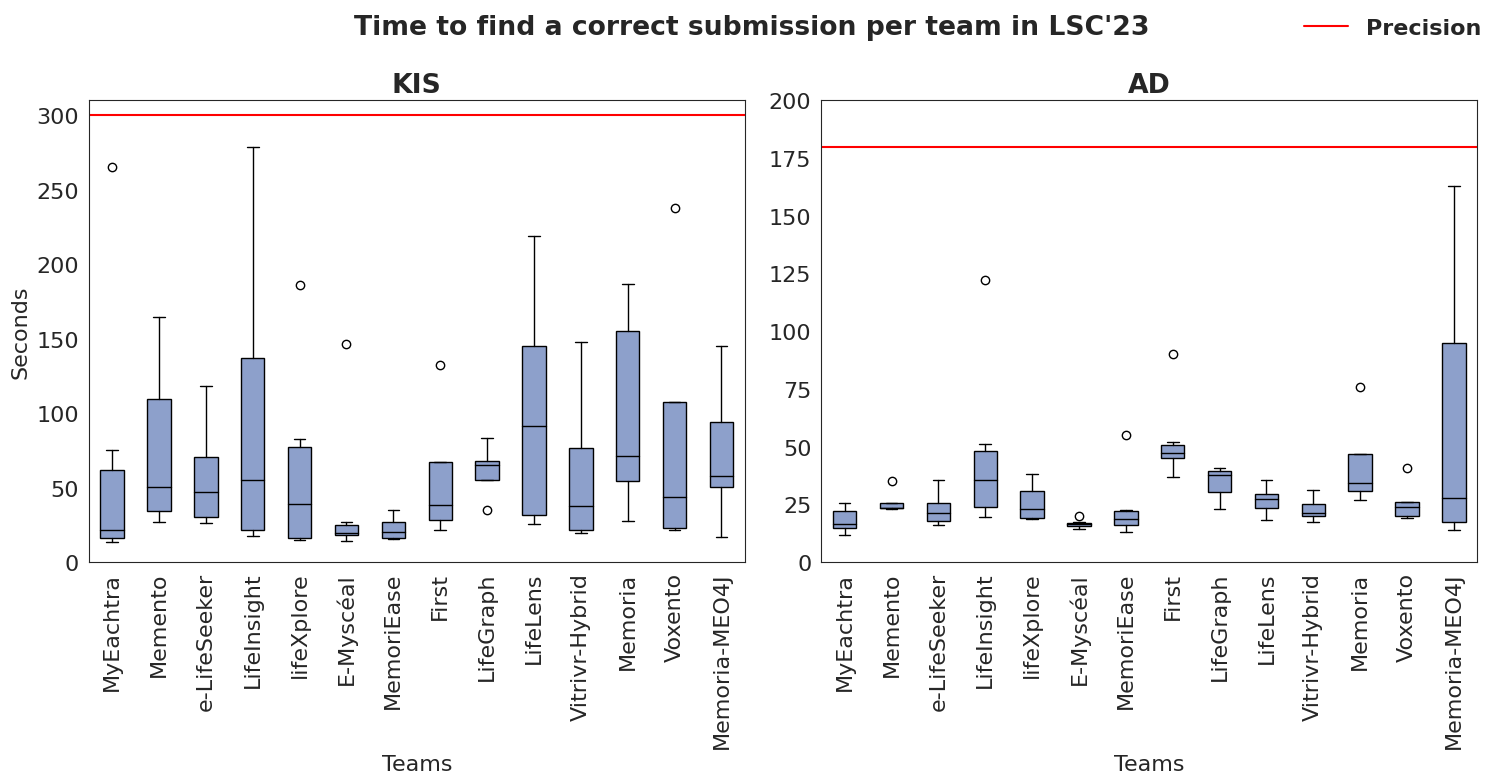

In [67]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# Create subplots
fig, axes = plt.subplots(1, len(task_names), figsize=(5 + len(task_names) * 5, 8))

# Plot data for each TASK
for i, TASK in enumerate(task_names):
    filtered = df[df["task"] == TASK]
    ax = filtered[[f"time_correct_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == TASK]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True,
        ax=axes[i])
    
    # ax.bar_label(ax.containers[0], labels=filtered["precision"], label_type='center')
    # ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"]], label_type='center')
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Seconds", va='center', rotation='vertical', transform=ax.transAxes)

    # set rotation of x-axis labels
    ax.tick_params(axis='x', rotation=90)
    
    # add a horizontal line for the limit (with label)
    ax.axhline(y=limits[TASK], color='r', linestyle='-', label=f"Time limit: {limits[TASK]}s")

    if TASK == "KIS":
        ax.set_ylim(0, 310)
    elif TASK == "QA":
        ax.set_ylim(0, 200)
    else:
        ax.set_ylim(0, 200)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')
    


# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Time to find a correct submission per team in LSC'23", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()

print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_23.png", format="png", bbox_inches='tight')

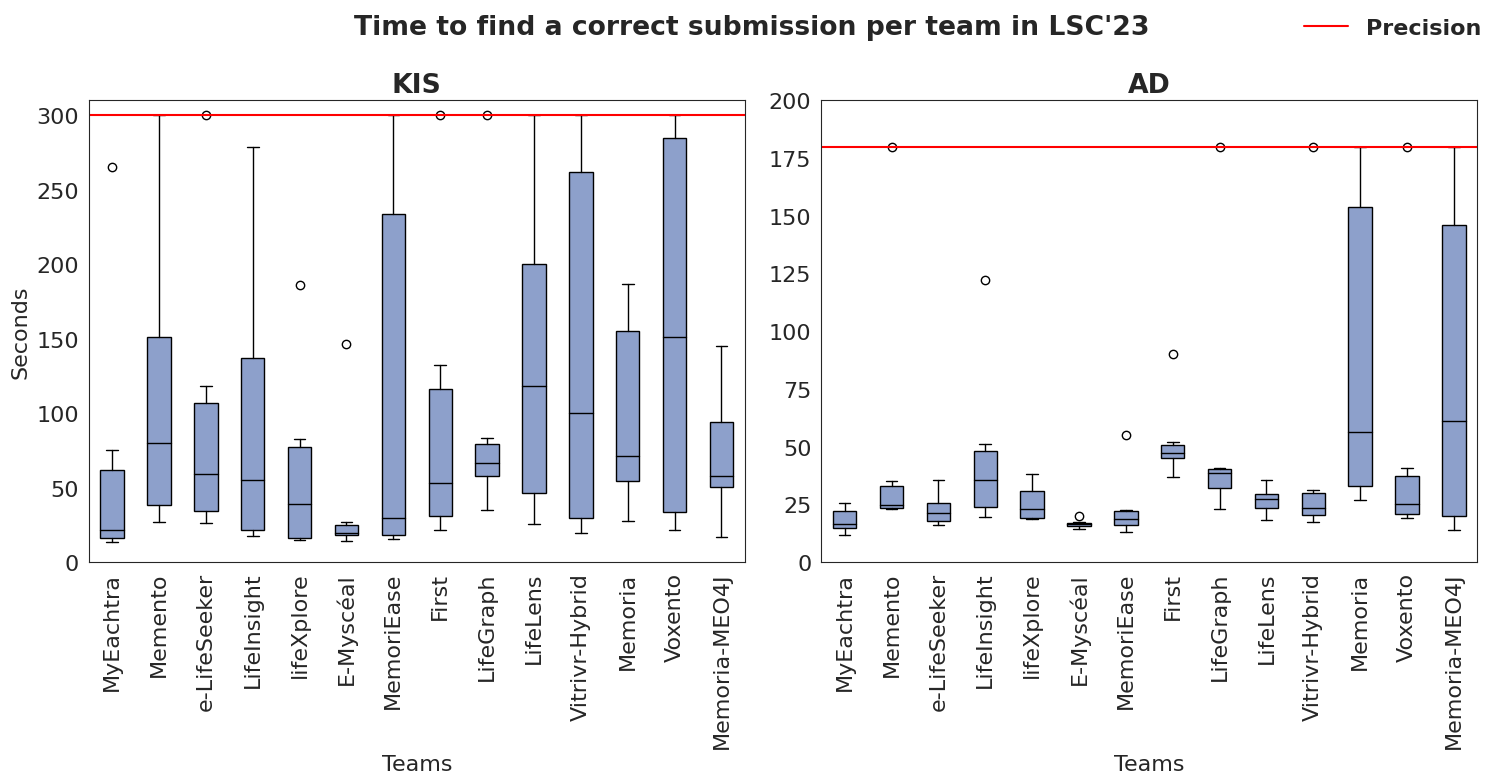

<Figure size 800x800 with 0 Axes>

In [68]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 16})

# Create subplots
fig, axes = plt.subplots(1, len(task_names), figsize=(5 + len(task_names) * 5, 8))

# Plot data for each TASK
for i, TASK in enumerate(task_names):
    filtered = df[df["task"] == TASK]
    ax = filtered[[f"time_correct_full_{i}" for i in time_till_correct["MyEachtra"] if task_type(i) == TASK]].T.plot(kind='box',
        showmeans=False, showfliers=True,
        boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
        patch_artist=True,
        ax=axes[i])
    
    # ax.bar_label(ax.containers[0], labels=filtered["precision"], label_type='center')
    # ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"]], label_type='center')
    # add a horizontal line for the limit (with label)
    ax.axhline(y=limits[TASK], color='r', linestyle='-', label=f"Time limit: {limits[TASK]}s")

    if TASK == "KIS":
        ax.set_ylim(0, 310)
    elif TASK == "QA":
        ax.set_ylim(0, 200)
    else:
        ax.set_ylim(0, 200)
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Seconds", va='center', rotation='vertical', transform=ax.transAxes)

    # set rotation of x-axis labels
    ax.tick_params(axis='x', rotation=90)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Precision", "Recall"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Time to find a correct submission per team in LSC'23", fontweight='bold')

# Add spacing between subplots
plt.tight_layout()
# Show the plot
plt.show()

print()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time_full_23.png", format="png", bbox_inches='tight')